<a href="https://colab.research.google.com/github/Sonukumar364/Healthrecommender/blob/fitness/healthupdated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as pl
import seaborn as sns

In [ ]:
# Load the dataset
data = pd.read_csv('user_data_with_recommendations.csv')

In [ ]:
# Inspecting the first few rows of the data
print(data.head())

           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366   2016-03-25       11004           7.11             7.11   
1  1503960366   2016-03-26       17609          11.55            11.55   
2  1503960366   2016-03-27       12736           8.53             8.53   
3  1503960366   2016-03-28       13231           8.93             8.93   
4  1503960366   2016-03-29       12041           7.85             7.85   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                2.57                      0.46   
1                       0.0                6.92                      0.73   
2                       0.0                4.66                      0.16   
3                       0.0                3.19                      0.79   
4                       0.0                2.16                      1.09   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0                 4.07

In [ ]:
# Handling missing values
data.dropna(inplace=True)

In [ ]:
# Selecting relevant features for clustering (modify based on columns in your dataset)
features = data[['TotalSteps', 'TotalDistance', 'Calories', 'VeryActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']]

In [ ]:
# Data normalization
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
inertia = []
silhouette_scores = []
davies_bouldin_scores = []

cluster_range = range(2, 11)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(scaled_features, kmeans.labels_))

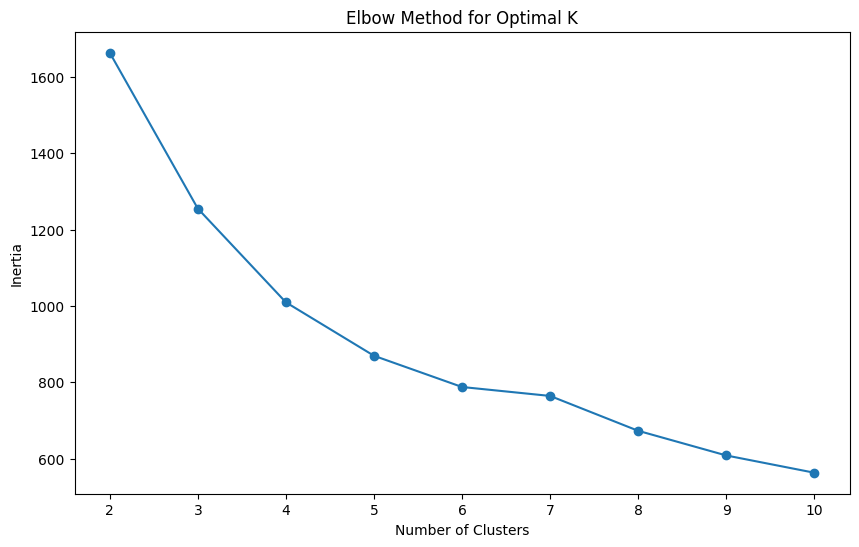

In [ ]:
# Plot Elbow Curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

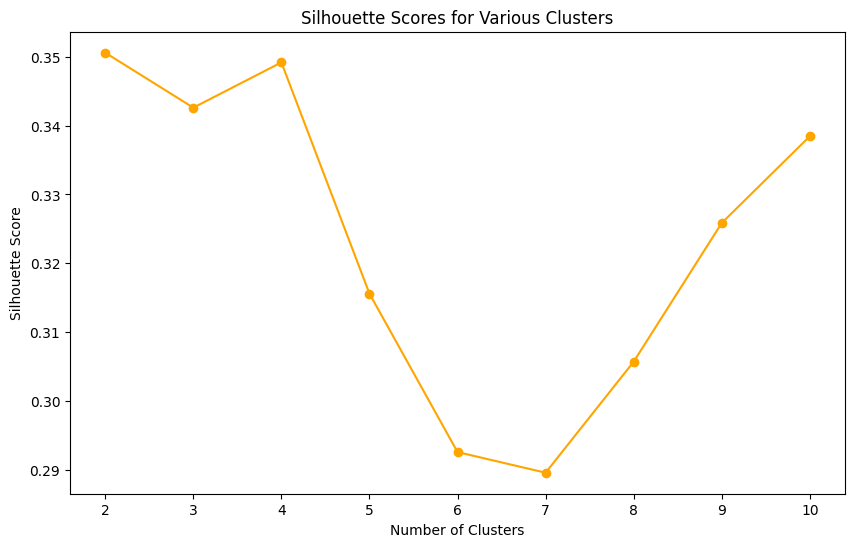

In [ ]:
# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Various Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

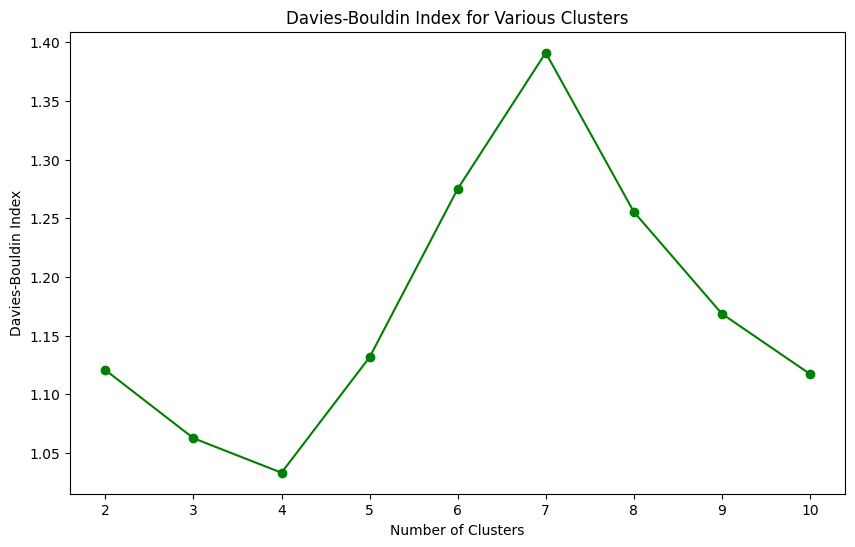

In [ ]:
# Plot Davies-Bouldin Scores
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, davies_bouldin_scores, marker='o', color='green')
plt.title('Davies-Bouldin Index for Various Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

In [ ]:
# Choosing optimal number of clusters (based on visual inspection)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [ ]:
# Adding cluster labels to the original data
data['Cluster'] = clusters

In [ ]:
# Summary of clusters
# Select only numeric columns for calculating the mean
cluster_summary = data.groupby('Cluster').agg({col: 'mean' for col in data.select_dtypes(include=['number']).columns})

print("Cluster Summary:\n", cluster_summary)

Cluster Summary:
                    Id    TotalSteps  TotalDistance  TrackerDistance  \
Cluster                                                               
0        4.496282e+09   1690.333333       1.170794         1.163069   
1        6.514026e+09  15234.431373      11.622157        11.529608   
2        4.300715e+09   8734.331797       6.070138         5.985576   

         LoggedActivitiesDistance  VeryActiveDistance  \
Cluster                                                 
0                        0.036570            0.055608   
1                        0.639581            6.244706   
2                        0.195705            0.970876   

         ModeratelyActiveDistance  LightActiveDistance  \
Cluster                                                  
0                        0.078519             0.848413   
1                        0.979608             4.378431   
2                        0.709401             4.318756   

         SedentaryActiveDistance  VeryActiveMinut

In [ ]:
# Example Recommendations based on cluster characteristics
recommendations = {
    0: "Increase daily steps and reduce sedentary time.",
    1: "Maintain current activity level, with focus on consistent active minutes.",
    2: "Focus on calorie management and increase vigorous activity."
}

In [ ]:
# Assigning recommendations to each user based on their cluster
data['Recommendation'] = data['Cluster'].map(recommendations)

In [ ]:
# Display the first few rows with recommendations
print(data[['Cluster', 'Recommendation']].head())

   Cluster                                     Recommendation
0        2  Focus on calorie management and increase vigor...
1        1  Maintain current activity level, with focus on...
2        2  Focus on calorie management and increase vigor...
3        2  Focus on calorie management and increase vigor...
4        2  Focus on calorie management and increase vigor...


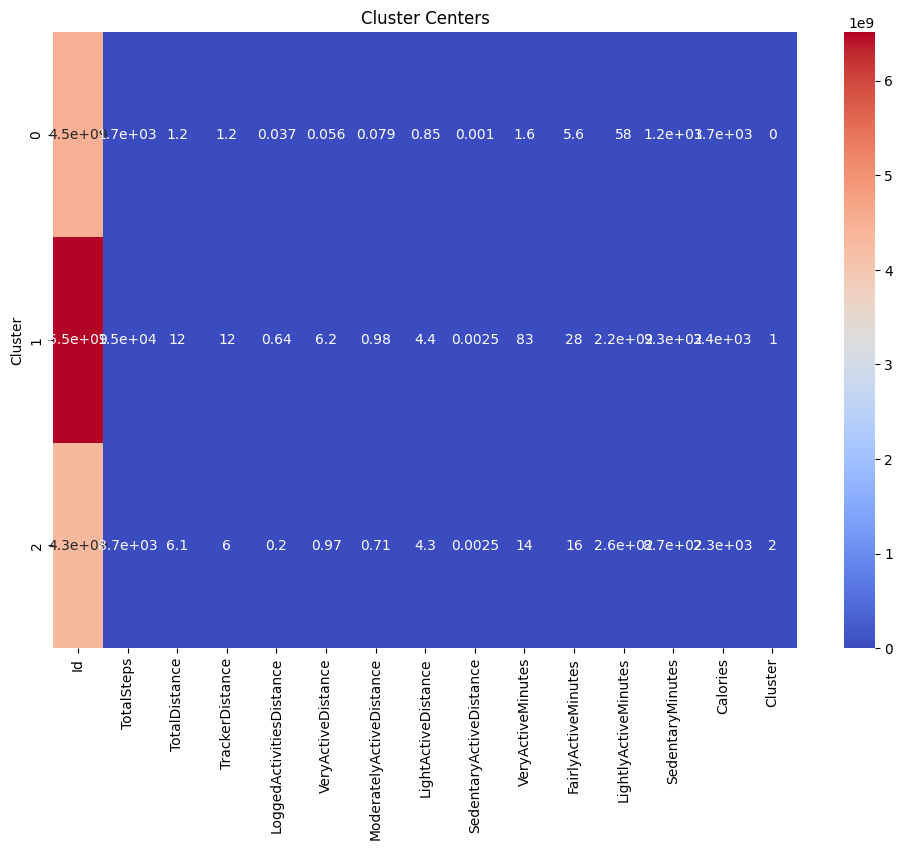

In [ ]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns # Importing seaborn with the alias 'sns'


# Visualize cluster centers
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm') # Now 'sns' is recognized
plt.title('Cluster Centers')
plt.show()

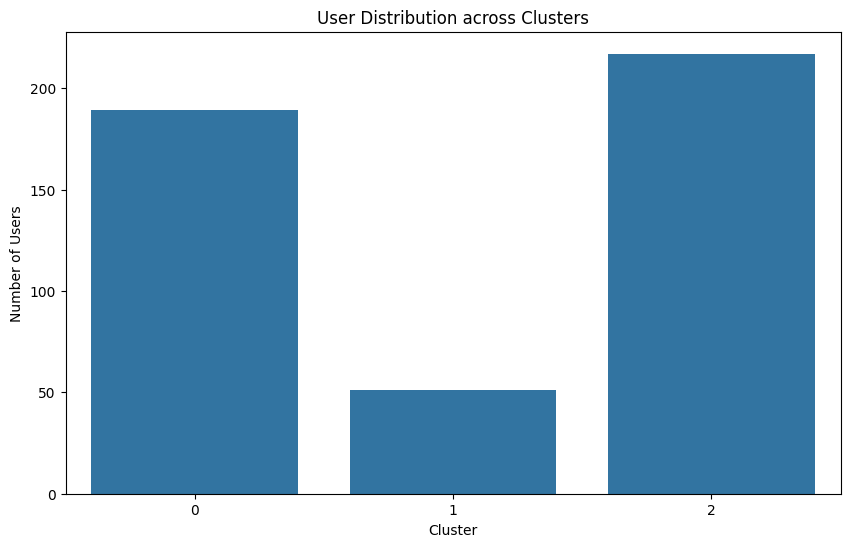

In [ ]:
# Displaying a count of users per recommendation category
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Cluster')
plt.title('User Distribution across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.show()

In [ ]:
# Final Evaluation Metrics
final_silhouette = silhouette_score(scaled_features, clusters)
final_davies_bouldin = davies_bouldin_score(scaled_features, clusters)

print(f'Silhouette Score for optimal k={optimal_k}: {final_silhouette:.4f}')
print(f'Davies-Bouldin Index for optimal k={optimal_k}: {final_davies_bouldin:.4f}')
print(f'Inertia for optimal k={optimal_k}: {kmeans.inertia_:.4f}')

Silhouette Score for optimal k=3: 0.3426
Davies-Bouldin Index for optimal k=3: 1.0625
Inertia for optimal k=3: 1254.8295
